<a href="https://colab.research.google.com/github/javmencia/RelativeBelief/blob/Round2/LinRegExperiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp
import numpy as np
from scipy.stats import norm, invgamma, multivariate_normal
import matplotlib.pyplot as plt

# Linear Regression

## Bias Against

### Hypothesis

In [2]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias against for the hypothesis problem using the sufficient statistic approach for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): Hypothesized beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): Hypothesized noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias against estimate or cumulative bias against values.
    """

    # Step 1: Generate synthetic datasets under the hypothesis
    p = X.shape[1]  # Number of predictors
    y = np.dot(X, beta0) + np.random.normal(0, np.sqrt(sigma0), size=(n_datasets, n_sample))

    # Step 2: Compute the log-likelihood of y under the hypothesis
    log_likelihood = multivariate_normal.logpdf(
        y, mean=np.dot(X, beta0), cov=sigma0 * np.eye(n_sample)
    )  # Shape: (n_datasets,)

    # Step 3: Sample beta and sigma^2 from their respective priors
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 4: Compute the marginal likelihood p(y | X) via Monte Carlo integration
    log_likelihoods = np.zeros((n_datasets, n_marginal))

    for i in range(n_marginal):
        mu_samples = np.dot(X, beta_samples[i])
        log_likelihoods[:, i] = multivariate_normal.logpdf(
            y, mean=mu_samples, cov=sigma_samples[i] * np.eye(n_sample)
        )

    # Compute log marginal likelihood for each y using log-sum-exp trick
    log_marginal_likelihood = logsumexp(log_likelihoods, axis=1) - np.log(n_marginal)

    # Step 5: Calculate bias against hypothesis
    bias_against = (log_likelihood - log_marginal_likelihood) <= 0

    # Compute cumulative bias against if requested
    bias_against_cumsum = np.cumsum(bias_against) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_against_cumsum[300:]
    else:
        return bias_against_cumsum[-1]



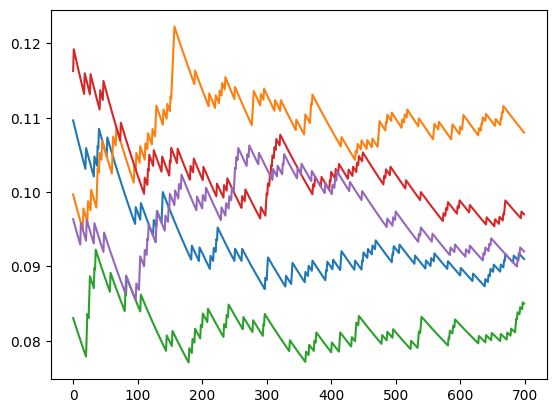

In [3]:
# With intercept
# Parameters
# Define prior parameters
mu_prior_mean = [1, 2, 4]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 3
X = np.ones((n, p))
X[:int(n/2),1] = 0
X[0:-1:2,2] = 0

# Ground truth parameters
beta0 = [1,2,4] #np.logspace(0, 1, 2, base=2)
sigma0 = 1
mu0 = np.dot(X, beta0)

loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = hypothesis_bias_against_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

In [4]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def estimation_bias_against_lin_reg(
    n_sample,
    X,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias against estimation using the sufficient statistic approach for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): Hypothesized beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): Hypothesized noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias against estimate or cumulative bias against values.
    """


    # Step 1: Sample p₀ from the prior distribution
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 2: Generate x from p(x | p₀)
    #y = np.dot(X, beta_samples) + np.random.normal(0, np.sqrt(sigma_samples), size=(n_datasets, n_sample))
    y = np.dot(X, beta_samples.T).T + np.random.normal(0, np.sqrt(sigma_samples)[:, np.newaxis], size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihoods of x under p₀
    log_likelihood = multivariate_normal.logpdf(
        y[:, np.newaxis], mean=np.dot(X, beta0), cov=sigma0 * np.eye(n_sample)
    )  # Shape: (n_datasets,)

    # Step 4: Sample p_j from the prior distribution
    #p_j_samples = np.random.beta(prior_alpha, prior_beta, size=n_marginal)
    beta_j_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_j_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(x) via Monte Carlo integration
    # Compute log p(x | p_j) for each p_j and x
    # Shape: (n_datasets, n_marginal)
    log_likelihoods = np.zeros((n_datasets, n_marginal))

    for i in range(n_marginal):
        mu_samples = np.dot(X, beta_j_samples[i])
        log_likelihoods[:, i] = multivariate_normal.logpdf(
            y, mean=mu_samples, cov=sigma_j_samples[i] * np.eye(n_sample)
        )


    # Compute log marginal likelihood for each x using log-sum-exp trick
    # log p(x) = log(1/n_marginal * sum_{j} exp(log p(x | p_j)))
    log_marginal_likelihood = logsumexp(log_likelihoods, axis=1) - np.log(n_marginal)

    # Step 6: Compute the bias against
    bias_against = (log_likelihood - log_marginal_likelihood) <= 0

    # Compute cumulative bias against if requested
    bias_against_cumsum = np.cumsum(bias_against) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_against_cumsum[300:]
    else:
        return bias_against_cumsum[-1]

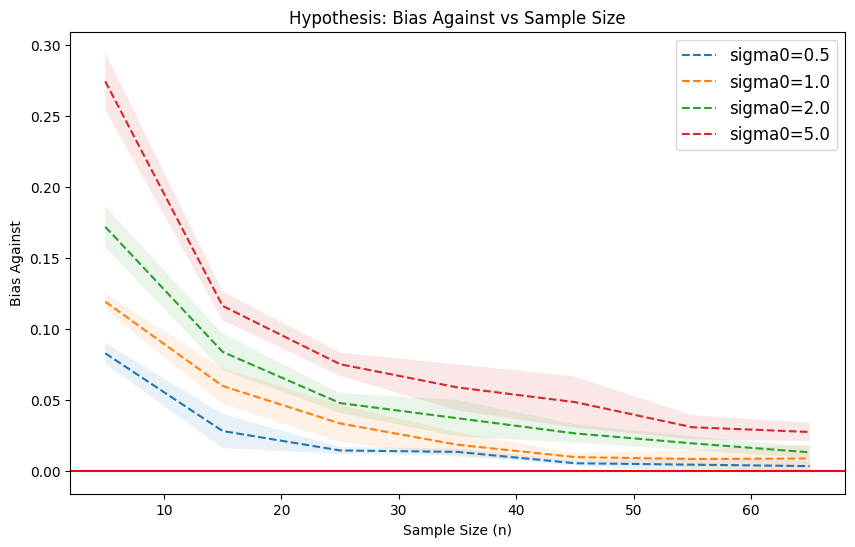

In [15]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    p = X.shape[1]  # Number of predictors
    y = np.dot(X, beta0) + np.random.normal(0, np.sqrt(sigma0), size=(n_datasets, n_sample))

    log_likelihood = multivariate_normal.logpdf(
        y, mean=np.dot(X, beta0), cov=sigma0 * np.eye(n_sample)
    )

    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    log_likelihoods = np.zeros((n_datasets, n_marginal))
    for i in range(n_marginal):
        mu_samples = np.dot(X, beta_samples[i])
        log_likelihoods[:, i] = multivariate_normal.logpdf(
            y, mean=mu_samples, cov=sigma_samples[i] * np.eye(n_sample)
        )

    log_marginal_likelihood = logsumexp(log_likelihoods, axis=1) - np.log(n_marginal)
    bias_against = (log_likelihood - log_marginal_likelihood) <= 0
    bias_against_cumsum = np.cumsum(bias_against) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_against_cumsum[300:]
    else:
        return bias_against_cumsum[-1]

# Parameters
mu_prior_mean = [1, 2, 4]
mu_prior_sigma = 1
beta0 = [1,2,4]#np.logspace(0, 1, 2, base=2)
p = 3

# Experiment with different values of sigma0 and corresponding hyperparameters
sigma_values = [0.5, 1.0, 2.0, 5.0]
sigma_prior_params = [(2, 0.5), (2, 1), (2, 2), (2, 5)]  # (alpha, beta) pairs for each sigma0

# Define n values
n_values = list(range(5, 70 + 1, 10))

plt.figure(figsize=(10, 6))

# Loop over different sigma0 values
for sigma0, (alpha, beta) in zip(sigma_values, sigma_prior_params):
    mean_values = []
    lower_bounds = []
    upper_bounds = []

    # Loop over different sample sizes
    for n in n_values:
        X = np.ones((n, p))
        X[:int(n / 2), 1] = 0
        X[0:-1:2, 2] = 0

        # Run the experiment 3 times for each point
        results = []
        for _ in range(3):
            bias_against_last = hypothesis_bias_against_lin_reg(
                n_sample=n,
                beta0=beta0,
                X=X,
                sigma0=sigma0,
                mu_prior_mean=mu_prior_mean,
                mu_prior_sigma=mu_prior_sigma,
                sigma_prior_alpha=alpha,
                sigma_prior_beta=beta,
                cumulative=False,
                n_datasets=1000
            )
            results.append(bias_against_last)

        # Calculate mean and 95% confidence intervals
        mean_bias = np.mean(results)
        std_bias = np.std(results)
        ci_lower = mean_bias - 1.96 * std_bias
        ci_upper = mean_bias + 1.96 * std_bias

        # Append results
        mean_values.append(mean_bias)
        lower_bounds.append(ci_lower)
        upper_bounds.append(ci_upper)

    # Plot the mean line with confidence intervals
    plt.plot(n_values, mean_values, linestyle='--', label=f'sigma0={sigma0}')
    plt.fill_between(n_values, lower_bounds, upper_bounds, alpha=0.1)

# Plotting details
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias Against")
plt.axhline(y = 0, color = 'r', linestyle = '-')
plt.title("Hypothesis: Bias Against vs Sample Size")
plt.legend(fontsize = "large")
plt.show()


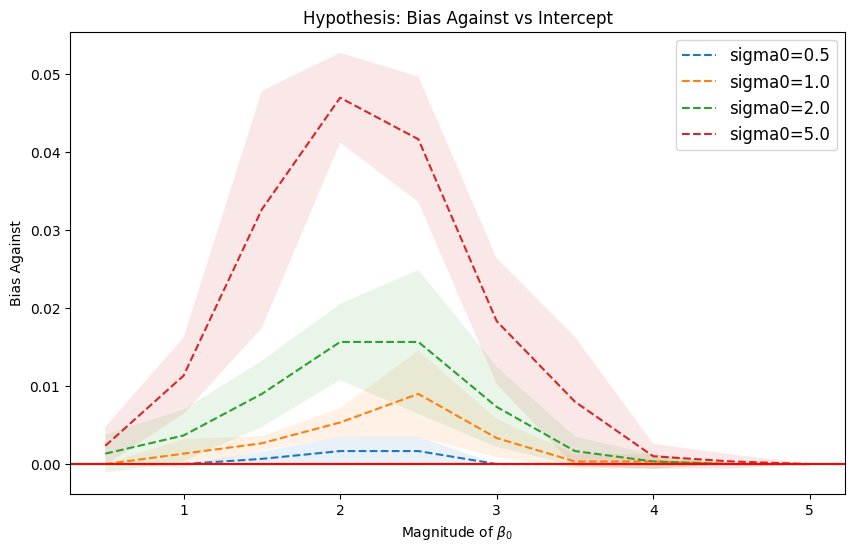

In [ ]:

# Parameters
mu_prior_mean = [1, 2, 4]
mu_prior_sigma = 1
p = 3
n_sample = 30  # Fixing sample size

# Experiment with different values of sigma0 and corresponding hyperparameters
sigma_values = [0.5, 1.0, 2.0, 5.0]
sigma_prior_params = [(2, 0.5), (2, 1), (2, 2), (2, 5)]  # (alpha, beta) pairs for each sigma0

# Define beta magnitudes for signal strength
beta_magnitudes = np.linspace(0.5, 5, 10)

plt.figure(figsize=(10, 6))

# Loop over different sigma0 values
for sigma0, (alpha, beta) in zip(sigma_values, sigma_prior_params):
    mean_values = []
    lower_bounds = []
    upper_bounds = []

    # Loop over different signal strengths
    for magnitude in beta_magnitudes:
        beta0 = [magnitude, magnitude, magnitude]  # Increase signal strength
        X = np.ones((n_sample, p))
        X[:int(n_sample / 2), 1] = 0
        X[0:-1:2, 2] = 0

        # Run the experiment 3 times for each point
        results = []
        for _ in range(3):
            bias_against_last = hypothesis_bias_against_lin_reg(
                n_sample=n_sample,
                beta0=beta0,
                X=X,
                sigma0=sigma0,
                mu_prior_mean=mu_prior_mean,
                mu_prior_sigma=mu_prior_sigma,
                sigma_prior_alpha=alpha,
                sigma_prior_beta=beta,
                cumulative=False,
                n_datasets=1000
            )
            results.append(bias_against_last)

        # Calculate mean and 95% confidence intervals
        mean_bias = np.mean(results)
        std_bias = np.std(results)
        ci_lower = mean_bias - 1.96 * std_bias
        ci_upper = mean_bias + 1.96 * std_bias

        # Append results
        mean_values.append(mean_bias)
        lower_bounds.append(ci_lower)
        upper_bounds.append(ci_upper)

    # Plot the mean line with confidence intervals
    plt.plot(beta_magnitudes, mean_values, linestyle='--', label=f'sigma0={sigma0}')
    plt.fill_between(beta_magnitudes, lower_bounds, upper_bounds, alpha=0.1)

# Plotting details
plt.xlabel("Magnitude of $\\beta_0$")
plt.ylabel("Bias Against")
plt.axhline(y=0, color='r', linestyle='-')
plt.title("Hypothesis: Bias Against vs Intercept")
plt.legend(fontsize="large")
plt.show()


### Estimation

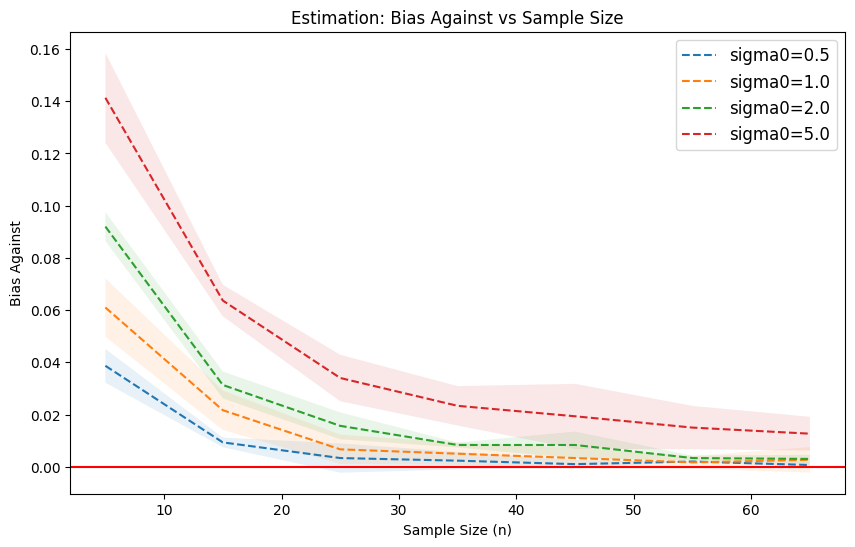

In [16]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def estimation_bias_against_lin_reg(
    n_sample,
    X,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias against estimation using the sufficient statistic approach for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): Hypothesized beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): Hypothesized noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias against estimate or cumulative bias against values.
    """


    # Step 1: Sample p₀ from the prior distribution
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 2: Generate x from p(x | p₀)
    #y = np.dot(X, beta_samples) + np.random.normal(0, np.sqrt(sigma_samples), size=(n_datasets, n_sample))
    y = np.dot(X, beta_samples.T).T + np.random.normal(0, np.sqrt(sigma_samples)[:, np.newaxis], size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihoods of x under p₀
    log_likelihood = np.zeros(n_datasets)
    for i in range(n_datasets):
        log_likelihood[i] = multivariate_normal.logpdf(
            y[i], mean=np.dot(X, beta_samples[i % n_marginal]), cov=sigma_samples[i % n_marginal] * np.eye(n_sample)
        )

    # Step 4: Sample p_j from the prior distribution
    #p_j_samples = np.random.beta(prior_alpha, prior_beta, size=n_marginal)
    beta_j_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_j_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(x) via Monte Carlo integration
    # Compute log p(x | p_j) for each p_j and x
    # Shape: (n_datasets, n_marginal)
    log_likelihoods = np.zeros((n_datasets, n_marginal))

    for i in range(n_marginal):
        mu_samples = np.dot(X, beta_j_samples[i])
        log_likelihoods[:, i] = multivariate_normal.logpdf(
            y, mean=mu_samples, cov=sigma_j_samples[i] * np.eye(n_sample)
        )


    # Compute log marginal likelihood for each x using log-sum-exp trick
    # log p(x) = log(1/n_marginal * sum_{j} exp(log p(x | p_j)))
    log_marginal_likelihood = logsumexp(log_likelihoods, axis=1) - np.log(n_marginal)

    # Step 6: Compute the bias against
    bias_against = (log_likelihood - log_marginal_likelihood) <= 0

    # Compute cumulative bias against if requested
    bias_against_cumsum = np.cumsum(bias_against) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_against_cumsum[300:]
    else:
        return bias_against_cumsum[-1]



# Parameters
mu_prior_mean = [1, 2, 4]
mu_prior_sigma = 1
p = 3

# Experiment with different values of sigma0 and corresponding hyperparameters
sigma_values = [0.5, 1.0, 2.0, 5.0]
sigma_prior_params = [(2, 0.5), (2, 1), (2, 2), (2, 5)]  # (alpha, beta) pairs for each sigma0

# Define n values
n_values = list(range(5, 70 + 1, 10))

plt.figure(figsize=(10, 6))

# Loop over different sigma0 values
for sigma0, (alpha, beta) in zip(sigma_values, sigma_prior_params):
    mean_values = []
    lower_bounds = []
    upper_bounds = []

    # Loop over different sample sizes
    for n in n_values:
        X = np.ones((n, p))
        X[:int(n / 2), 1] = 0
        X[0:-1:2, 2] = 0

        # Run the experiment 3 times for each point
        results = []
        for _ in range(3):
            bias_against_last = estimation_bias_against_lin_reg(
                n_sample=n,
                X=X,
                mu_prior_mean=mu_prior_mean,
                mu_prior_sigma=mu_prior_sigma,
                sigma_prior_alpha=alpha,
                sigma_prior_beta=beta,
                cumulative=False,
                n_datasets=1000
            )
            results.append(bias_against_last)

        # Calculate mean and 95% confidence intervals
        mean_bias = np.mean(results)
        std_bias = np.std(results)
        ci_lower = mean_bias - 1.96 * std_bias
        ci_upper = mean_bias + 1.96 * std_bias

        # Append results
        mean_values.append(mean_bias)
        lower_bounds.append(ci_lower)
        upper_bounds.append(ci_upper)

    # Plot the mean line with confidence intervals
    plt.plot(n_values, mean_values, linestyle='--', label=f'sigma0={sigma0}')
    plt.fill_between(n_values, lower_bounds, upper_bounds, alpha=0.1)

# Plotting details
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias Against")
plt.axhline(y = 0, color = 'r', linestyle = '-')
plt.title("Estimation: Bias Against vs Sample Size")
plt.legend(fontsize = "large")
plt.show()


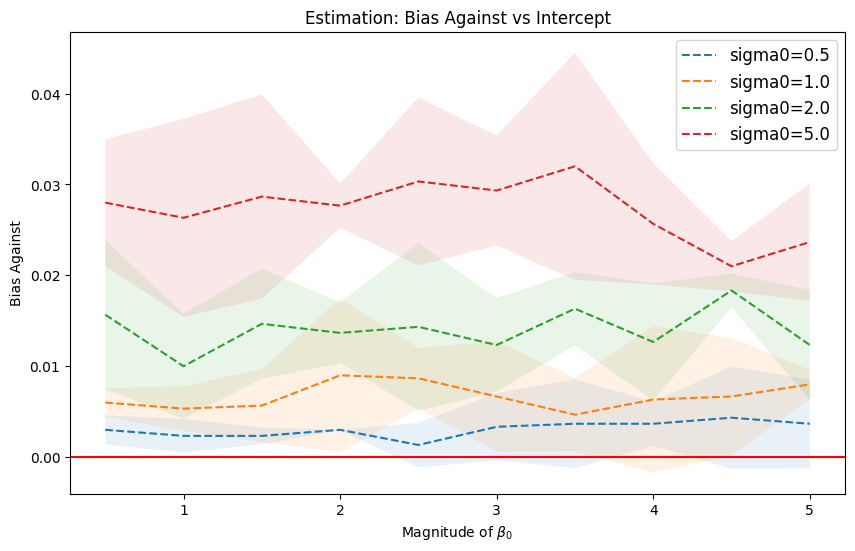

In [11]:

# Parameters
mu_prior_mean = [1, 2, 4]
mu_prior_sigma = 1
p = 3
n_sample = 30  # Fixing sample size

# Experiment with different values of sigma0 and corresponding hyperparameters
sigma_values = [0.5, 1.0, 2.0, 5.0]
sigma_prior_params = [(2, 0.5), (2, 1), (2, 2), (2, 5)]  # (alpha, beta) pairs for each sigma0

# Define beta magnitudes for signal strength
beta_magnitudes = np.linspace(0.5, 5, 10)

plt.figure(figsize=(10, 6))

# Loop over different sigma0 values
for sigma0, (alpha, beta) in zip(sigma_values, sigma_prior_params):
    mean_values = []
    lower_bounds = []
    upper_bounds = []

    # Loop over different signal strengths
    for magnitude in beta_magnitudes:
        beta0 = [magnitude, magnitude, magnitude]  # Increase signal strength
        X = np.ones((n_sample, p))
        X[:int(n_sample / 2), 1] = 0
        X[0:-1:2, 2] = 0

        # Run the experiment 3 times for each point
        results = []
        for _ in range(3):
            bias_against_last = estimation_bias_against_lin_reg(
                n_sample=n_sample,
                X=X,
                mu_prior_mean=mu_prior_mean,
                mu_prior_sigma=mu_prior_sigma,
                sigma_prior_alpha=alpha,
                sigma_prior_beta=beta,
                cumulative=False,
                n_datasets=1000
            )
            results.append(bias_against_last)

        # Calculate mean and 95% confidence intervals
        mean_bias = np.mean(results)
        std_bias = np.std(results)
        ci_lower = mean_bias - 1.96 * std_bias
        ci_upper = mean_bias + 1.96 * std_bias

        # Append results
        mean_values.append(mean_bias)
        lower_bounds.append(ci_lower)
        upper_bounds.append(ci_upper)

    # Plot the mean line with confidence intervals
    plt.plot(beta_magnitudes, mean_values, linestyle='--', label=f'sigma0={sigma0}')
    plt.fill_between(beta_magnitudes, lower_bounds, upper_bounds, alpha=0.1)

# Plotting details
plt.xlabel("Magnitude of $\\beta_0$")
plt.ylabel("Bias Against")
plt.axhline(y=0, color='r', linestyle='-')
plt.title("Estimation: Bias Against vs Intercept")
plt.legend(fontsize="large")
plt.show()


## Bias In Favor

In [21]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma, norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias in favor of a hypothesis for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): True beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): True noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - delta (float): Adjustment to create alternative hypotheses.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias in favor estimate or cumulative bias values.
    """

    p = X.shape[1]  # Number of predictors
    n = X.shape[0]  # Number of samples

    # Step 1: Create perturbed beta values (for hypotheses in favor)
    beta_perturbed = []
    for i in range(p):
        for sign in [-1, 1]:  # Perturb each coefficient positively and negatively
            beta_new = beta0.copy()
            beta_new[i] += sign * delta
            beta_perturbed.append(beta_new)

    beta_perturbed = np.array(beta_perturbed)
    # Step 2: Generate synthetic datasets
    y = np.dot(X, beta0) + np.random.normal(0, np.sqrt(sigma0), size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihood under the perturbed hypotheses
    log_likelihoods = np.zeros((len(beta_perturbed), n_datasets))
    for idx, beta_hyp in enumerate(beta_perturbed):
        log_likelihoods[idx, :] = multivariate_normal.logpdf(
            y, mean=np.dot(X, beta_hyp), cov=sigma0 * np.eye(n_sample)
        )

    # Step 4: Sample beta and sigma^2 from their respective priors
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(y | X) via Monte Carlo integration
    log_marginal_likelihoods = np.zeros((n_datasets,))
    for d in range(n_datasets):
        marginal_likelihood_samples = np.zeros((n_marginal,))
        for i in range(n_marginal):
            mean_sample = np.dot(X, beta_samples[i])
            marginal_likelihood_samples[i] = multivariate_normal.logpdf(
                y[d], mean=mean_sample, cov=sigma_samples[i] * np.eye(n_sample)
            )
        log_marginal_likelihoods[d] = logsumexp(marginal_likelihood_samples) - np.log(n_marginal)

    # Step 6: Calculate bias in favor
    bias_in_favor = np.any(log_likelihoods >= log_marginal_likelihoods, axis=0)

    # Step 7: Compute cumulative bias in favor if requested
    bias_in_favor_cumsum = np.cumsum(bias_in_favor) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_in_favor_cumsum[300:]
    else:
        return bias_in_favor_cumsum[-1]


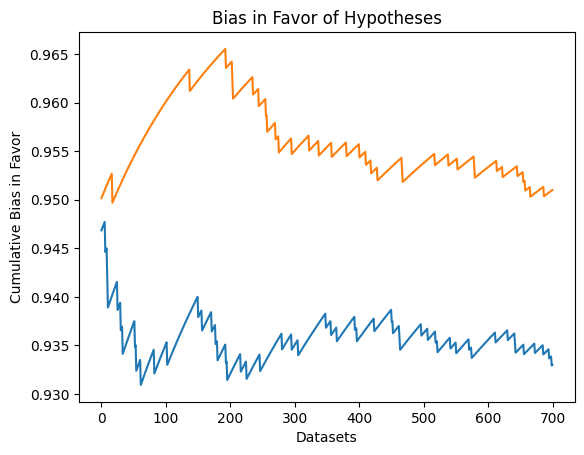

In [22]:

# Parameters
mu_prior_mean = [1, 2, 4]
mu_prior_sigma = np.eye(3)
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 3
X = np.ones((n, p))
X[:int(n / 2), 1] = 0
X[0:-1:2, 2] = 0

# Ground truth parameters
beta0 = [1, 2, 4]
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000,
        n_marginal=1000,
    )
    plt.plot(bias_in_favor)

plt.xlabel("Datasets")
plt.ylabel("Cumulative Bias in Favor")
plt.title("Bias in Favor of Hypotheses")
plt.show()


[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]


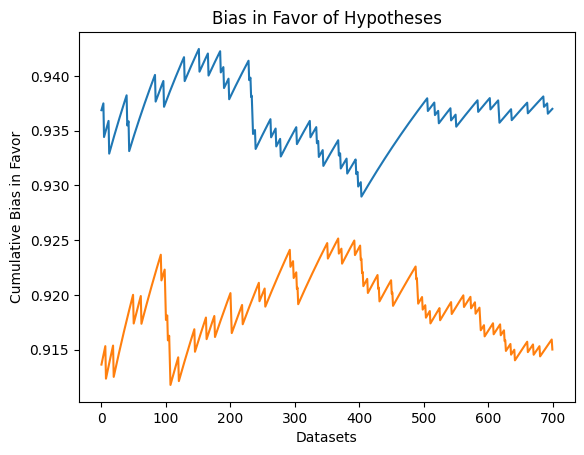

In [7]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma, norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias in favor of a hypothesis for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): True beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): True noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - delta (float): Adjustment to create alternative hypotheses.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias in favor estimate or cumulative bias values.
    """

    p = X.shape[1]  # Number of predictors
    n = X.shape[0]  # Number of samples

    # Step 1: Create perturbed beta values (for hypotheses in favor)
    beta_perturbed = []
    for i in range(p):
        for sign in [-1, 1]:  # Perturb each coefficient positively and negatively
            beta_new = beta0.copy()
            beta_new[i] += sign * delta
            beta_perturbed.append(beta_new)

    beta_perturbed = np.array(beta_perturbed)
    print(beta_perturbed)
    # Step 2: Generate synthetic datasets
    y = np.dot(X, beta0) + np.random.normal(0, np.sqrt(sigma0), size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihood under the perturbed hypotheses
    log_likelihoods = np.zeros((len(beta_perturbed), n_datasets))
    for idx, beta_hyp in enumerate(beta_perturbed):
        log_likelihoods[idx, :] = multivariate_normal.logpdf(
            y, mean=np.dot(X, beta_hyp), cov=sigma0 * np.eye(n_sample)
        )

    # Step 4: Sample beta and sigma^2 from their respective priors
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(y | X) via Monte Carlo integration
    log_marginal_likelihoods = np.zeros((n_datasets,))
    for d in range(n_datasets):
        marginal_likelihood_samples = np.zeros((n_marginal,))
        for i in range(n_marginal):
            mean_sample = np.dot(X, beta_samples[i])
            marginal_likelihood_samples[i] = multivariate_normal.logpdf(
                y[d], mean=mean_sample, cov=sigma_samples[i] * np.eye(n_sample)
            )
        log_marginal_likelihoods[d] = logsumexp(marginal_likelihood_samples) - np.log(n_marginal)

    # Step 6: Calculate bias in favor
    bias_in_favor = np.any(log_likelihoods >= log_marginal_likelihoods, axis=0)

    # Step 7: Compute cumulative bias in favor if requested
    bias_in_favor_cumsum = np.cumsum(bias_in_favor) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_in_favor_cumsum[300:]
    else:
        return bias_in_favor_cumsum[-1]


# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = np.eye(2)
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
#X[:int(n / 2), 1] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = [1, 2]#np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000,
        n_marginal=1000,
    )
    plt.plot(bias_in_favor)

plt.xlabel("Datasets")
plt.ylabel("Cumulative Bias in Favor")
plt.title("Bias in Favor of Hypotheses")
plt.show()
